In [1]:
# 1. Module Imports

# 1. Data processing
import pandas as pd
import numpy as np

# 2. Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='darkgrid', font_scale=1.3)
plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

# 3. Statistical analysis
from scipy.stats import chi2_contingency  # Chi-square test
from scipy.stats import levene            # Levene’s test for homogeneity of variance
from scipy.stats import f_oneway          # One-way ANOVA

# 4. Feature engineering
import sklearn
from sklearn import preprocessing          # Data preprocessing
from sklearn.preprocessing import LabelEncoder  # Label encoding
from sklearn.preprocessing import StandardScaler  # Standardization
from sklearn.model_selection import StratifiedShuffleSplit  # Stratified sampling
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split  # Train-test split
from sklearn.decomposition import PCA      # Principal Component Analysis (dimensionality reduction)

# 5. Classification algorithms
from sklearn.ensemble import RandomForestClassifier  # Random Forest
from sklearn.svm import SVC, LinearSVC               # Support Vector Machine
from sklearn.linear_model import LogisticRegression   # Logistic Regression
from sklearn.neighbors import KNeighborsClassifier    # K-Nearest Neighbors
from sklearn.cluster import KMeans                    # K-Means clustering
from sklearn.naive_bayes import GaussianNB            # Naive Bayes
from sklearn.tree import DecisionTreeClassifier       # Decision Tree

# 6. Ensemble learning algorithms
import xgboost as xgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

# 7. Model evaluation
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    silhouette_score,
    make_scorer
)
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import VotingClassifier

# 8. Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 2. Data Cleaning

# 1. Load data
df = pd.read_csv(r'WA_Fn-UseC_-Telco-Customer-Churn.csv', header=0)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)

print(df.head())
print(df.shape)

# 2. Data cleaning
print('Missing values\n', df.isnull().sum())
print('Duplicate values\n', df.duplicated().sum())
print('Data types', df.info())

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].dtype)

print('Second missing value check\n', df.isnull().sum())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling              PaymentMethod  MonthlyCharges TotalCharges Churn
0  7590-VHVEG  Female              0     Yes         No       1           No  No phone service             DSL             No          Yes               No          No          No              No  Month-to-month              Yes           Electronic check           29.85        29.85    No
1  5575-GNVDE    Male              0      No         No      34          Yes                No             DSL            Yes           No              Yes          No          No              No        One year               No               Mailed check           56.95       1889.5    No
2  3668-QPYBK    Male              0      No         No       2          Yes                No             DSL            Yes  

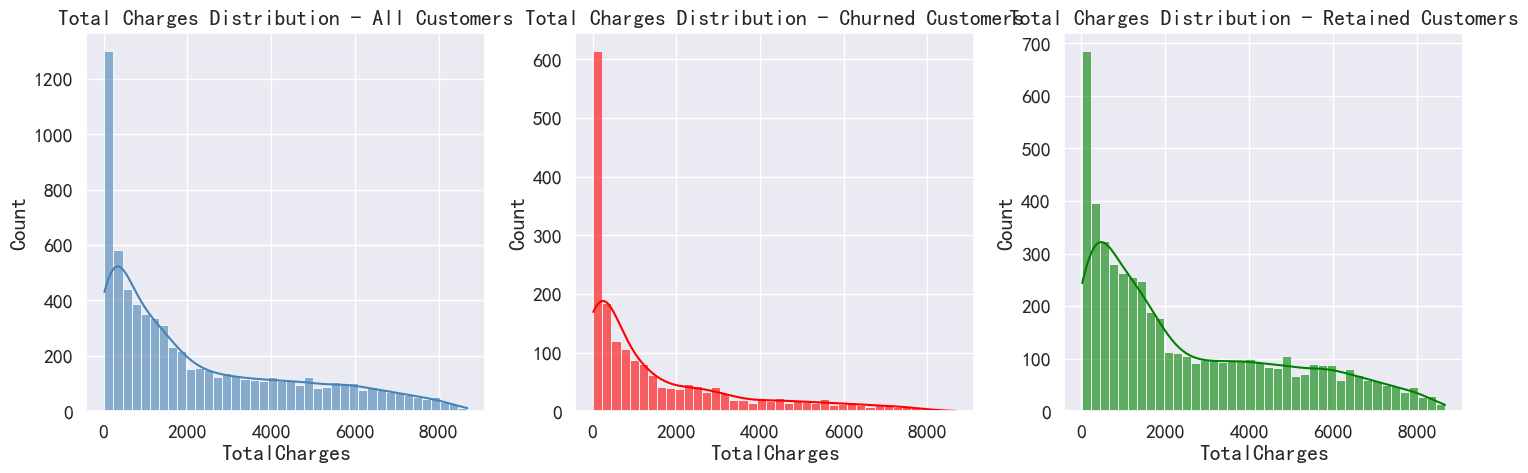

Missing values after median imputation
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [3]:
# ===== Improved Visualization (No logic change) =====

plt.figure(figsize=(15, 5))

# 1. All customers
plt.subplot(1, 3, 1)
plt.title('Total Charges Distribution - All Customers')

sns.histplot(
    df['TotalCharges'].dropna(),
    kde=True,
    bins=40,
    color='steelblue',
    alpha=0.6
)

# 2. Churned customers
plt.subplot(1, 3, 2)
plt.title('Total Charges Distribution - Churned Customers')

sns.histplot(
    df[df['Churn'] == 'Yes']['TotalCharges'].dropna(),
    kde=True,
    bins=40,
    color='red',
    alpha=0.6
)

# 3. Retained customers
plt.subplot(1, 3, 3)
plt.title('Total Charges Distribution - Retained Customers')

sns.histplot(
    df[df['Churn'] == 'No']['TotalCharges'].dropna(),
    kde=True,
    bins=40,
    color='green',
    alpha=0.6
)

plt.tight_layout()
plt.show()

# ===== Missing value handling =====
df.fillna({'TotalCharges': df['TotalCharges'].median()}, inplace=True)
print('Missing values after median imputation\n', df.isnull().sum())

median imputation

Data Insight：

Churned customers tend to have lower TotalCharges
Retained customers show higher and wider distribution

Preview of encoded Churn 0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


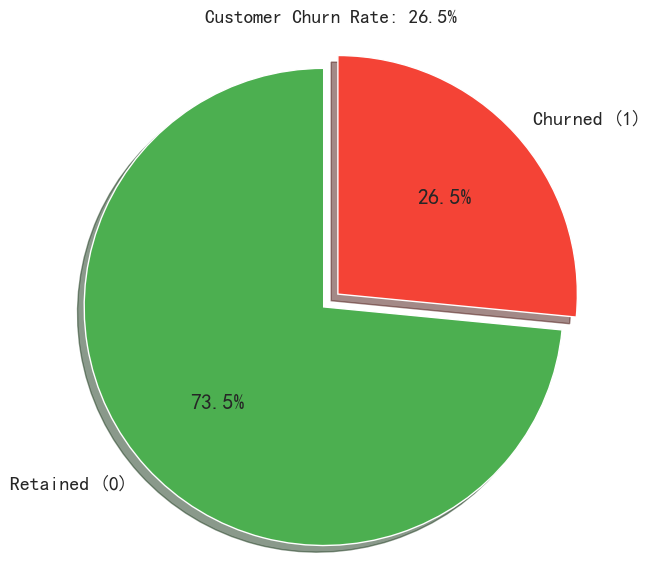

In [4]:
# ===== Encode Churn (unchanged logic) =====
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print('Preview of encoded Churn', df['Churn'].head())

# ===== Value count =====
churn_value = df['Churn'].value_counts().sort_index()
labels = ['Retained (0)', 'Churned (1)']

# churn percentage
churn_per = churn_value[1] / churn_value.sum() * 100

# ===== Plot =====
plt.figure(figsize=(7, 7))

colors = ['#4CAF50', '#F44336']  # green = retained, red = churn

plt.pie(
    churn_value,
    labels=labels,
    colors=colors,
    explode=(0, 0.08),
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

plt.title(f'Customer Churn Rate: {churn_per:.1f}%', fontsize=14)
plt.axis('equal')
plt.show()

The dataset is imbalanced, with significantly more retained customers than churned ones, which may bias predictive models.

Integer encoding of features
    gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  MultipleLines  InternetService  OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  PaperlessBilling  PaymentMethod  MonthlyCharges  TotalCharges
0       0              0        0           0       0             0              0                0               0             0                 0            0            0                0         0                 0              0               0             0
1       1              0        1           0       1             1              1                0               1             1                 1            0            0                0         1                 1              1               1             1
2       1              0        1           0       2             1              1                0               1             0                 0            0            0     

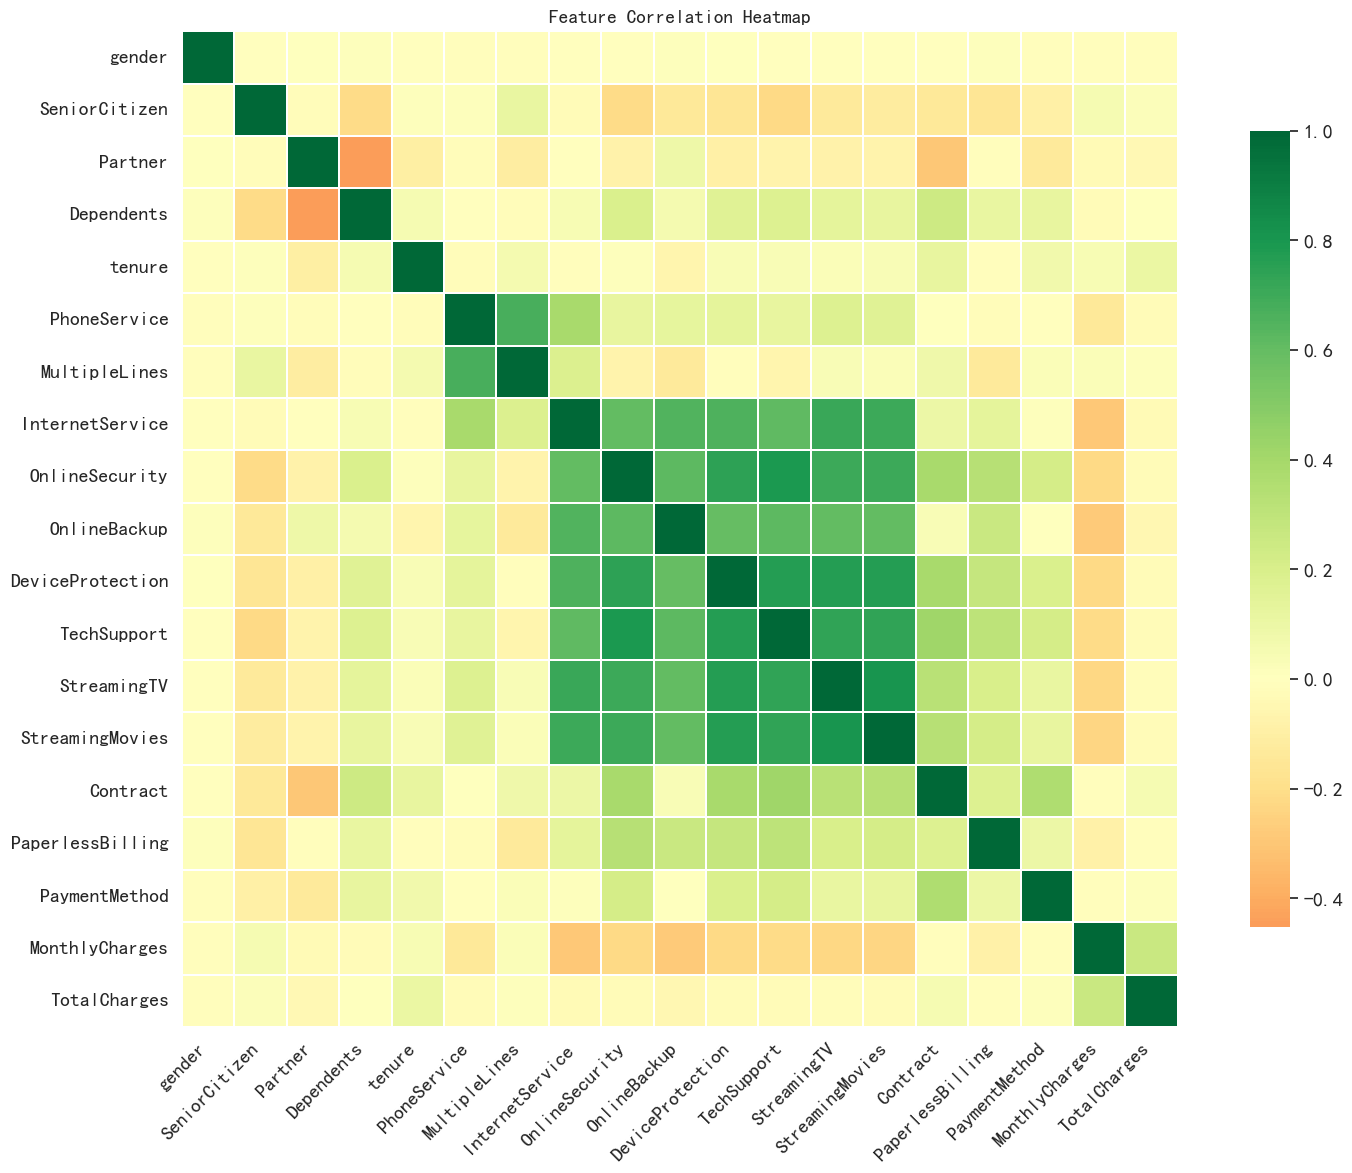

In [5]:
# ===== Feature selection =====
features = df.iloc[:, 1:20]

# ===== Encode categorical features =====
corr_df = features.apply(lambda x: pd.factorize(x)[0])
print('Integer encoding of features\n', corr_df.head())

# ===== Correlation matrix =====
corr = corr_df.corr()
print('Feature correlation matrix\n', corr)

# ===== Plot (optimized) =====
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    cmap='RdYlGn',
    linewidths=0.3,
    center=0,              
    square=True,           
    cbar_kws={'shrink': 0.8}, 
    annot=False           
)

plt.title('Feature Correlation Heatmap', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

📊 Full correlation with Churn:

Contract_Month-to-month                    0.405103
OnlineSecurity_No                          0.342637
TechSupport_No                             0.337281
InternetService_Fiber optic                0.308020
PaymentMethod_Electronic check             0.301919
OnlineBackup_No                            0.268005
DeviceProtection_No                        0.252481
MonthlyCharges                             0.193356
PaperlessBilling_Yes                       0.191825
Dependents_No                              0.164221
SeniorCitizen                              0.150889
Partner_No                                 0.150448
StreamingMovies_No                         0.130845
StreamingTV_No                             0.128916
StreamingTV_Yes                            0.063228
StreamingMovies_Yes                        0.061382
MultipleLines_Yes                          0.040102
PhoneService_Yes                           0.011942
gender_Female                   

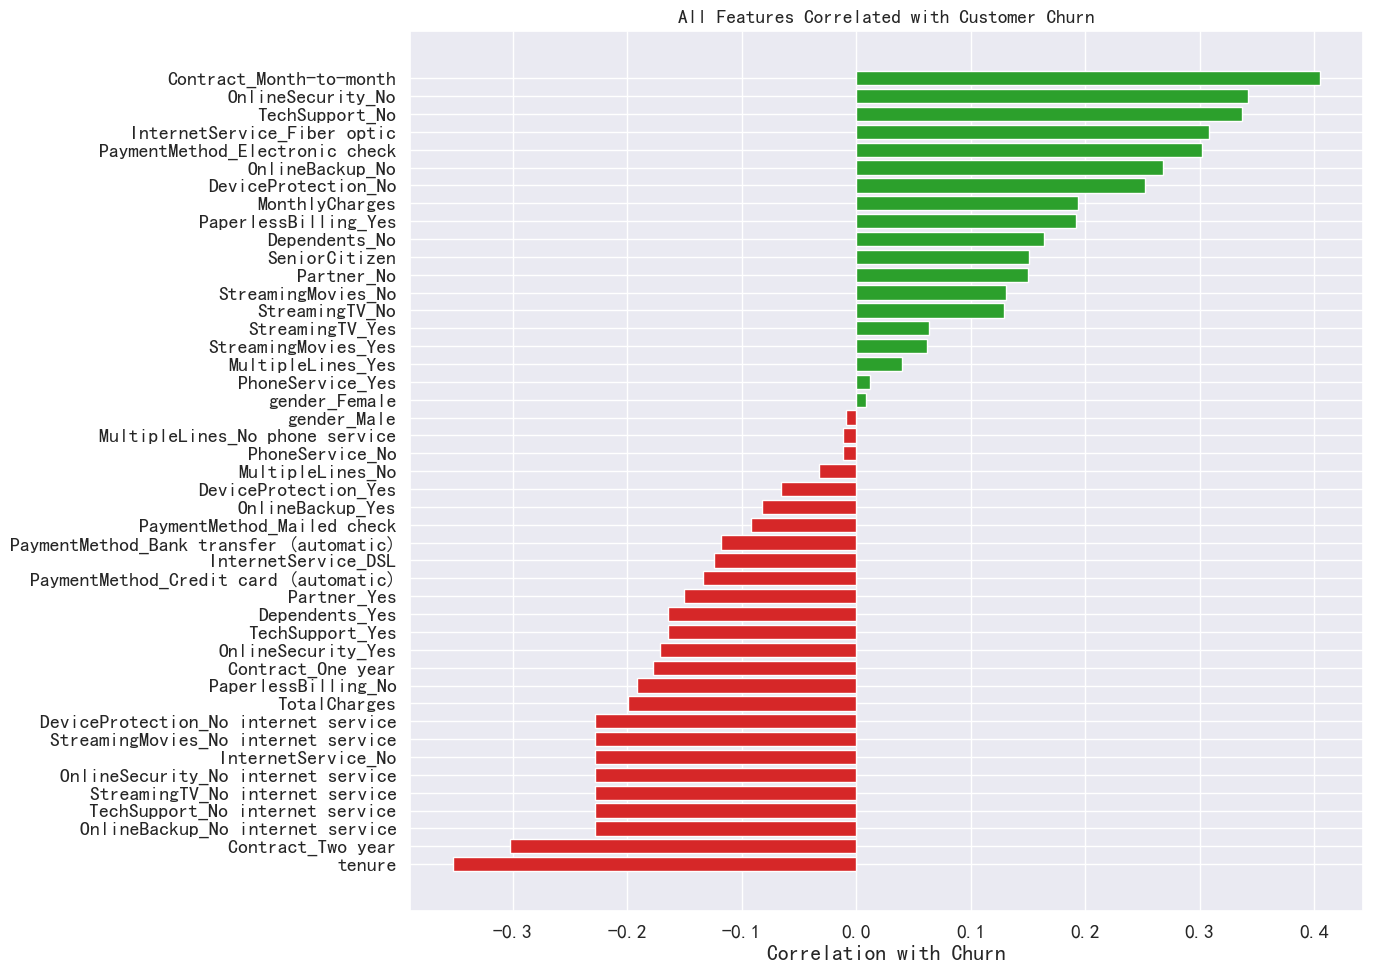

In [6]:
# ===== One-hot encoding =====
df_onehot = pd.get_dummies(df.iloc[:, 1:21])

# ===== Correlation with Churn =====
churn_corr = df_onehot.corr()['Churn'].sort_values(ascending=False)

churn_corr = churn_corr.drop('Churn')

print("📊 Full correlation with Churn:\n")
print(churn_corr)

# ===== Plot (ALL features) =====
plt.figure(figsize=(14, 10))

colors = ['#d62728' if x < 0 else '#2ca02c' for x in churn_corr.values]

plt.barh(
    churn_corr.index,
    churn_corr.values,
    color=colors
)

plt.title('All Features Correlated with Customer Churn', fontsize=14)
plt.xlabel('Correlation with Churn')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Contract type is the strongest predictor of churn, with short-term contracts significantly increasing churn probability.

Lack of technical support and security services strongly increases churn risk.

Customer tenure is the most stable retention factor, indicating that long-term customers are significantly less likely to churn.

Electronic check users show higher churn risk, while automatic payment methods improve retention.

Fiber optic users are more likely to churn compared to DSL users, potentially due to pricing or service expectations.

The unexpected negative correlation between TotalCharges and churn is likely due to multicollinearity with tenure, as both variables capture customer duration effects.

In [7]:
kf_var = df.columns.drop(['gender', 'PhoneService', 'customerID', 'Churn']).tolist()

print('kf_var=', kf_var)

kf_var= ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [8]:
def KF(x):
    df1 = pd.crosstab(df['Churn'], df[x])
    li1 = list(df1.iloc[0, :])
    li2 = list(df1.iloc[1, :])
    kf_data = np.array([li1, li2])

    kf = chi2_contingency(kf_data)
    p_value = kf[1]

    if p_value < 0.05:
        print(
            'Chi-square test p-value for churn by {} is {:.2e}, less than 0.05, indicating significant differences between groups, suitable for [cross-analysis]'
            .format(x, p_value),
            '\n'
        )
    else:
        print(
            'Chi-square test p-value for churn by {} is {:.2e}, greater than 0.05, not suitable for cross-analysis'
            .format(x, p_value),
            '\n'
        )

print('Chi-square test results between high-correlation features (kf_var) and customer churn:\n')
list(map(KF, kf_var))

Chi-square test results between high-correlation features (kf_var) and customer churn:

Chi-square test p-value for churn by SeniorCitizen is 1.51e-36, less than 0.05, indicating significant differences between groups, suitable for [cross-analysis] 

Chi-square test p-value for churn by Partner is 2.14e-36, less than 0.05, indicating significant differences between groups, suitable for [cross-analysis] 

Chi-square test p-value for churn by Dependents is 4.92e-43, less than 0.05, indicating significant differences between groups, suitable for [cross-analysis] 

Chi-square test p-value for churn by tenure is 1.28e-176, less than 0.05, indicating significant differences between groups, suitable for [cross-analysis] 

Chi-square test p-value for churn by MultipleLines is 3.46e-03, less than 0.05, indicating significant differences between groups, suitable for [cross-analysis] 

Chi-square test p-value for churn by InternetService is 9.57e-160, less than 0.05, indicating significant differ

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

A chi-square test of independence was conducted to examine the relationship between categorical features and customer churn.

The results indicate that most service-related features, including internet service type, technical support, and security services, are statistically significantly associated with churn (p < 0.05). This suggests that product engagement and service adoption play a critical role in customer retention.

In contrast, TotalCharges does not show a statistically significant relationship with churn (p > 0.05), indicating that it is not a direct driver of churn behavior.

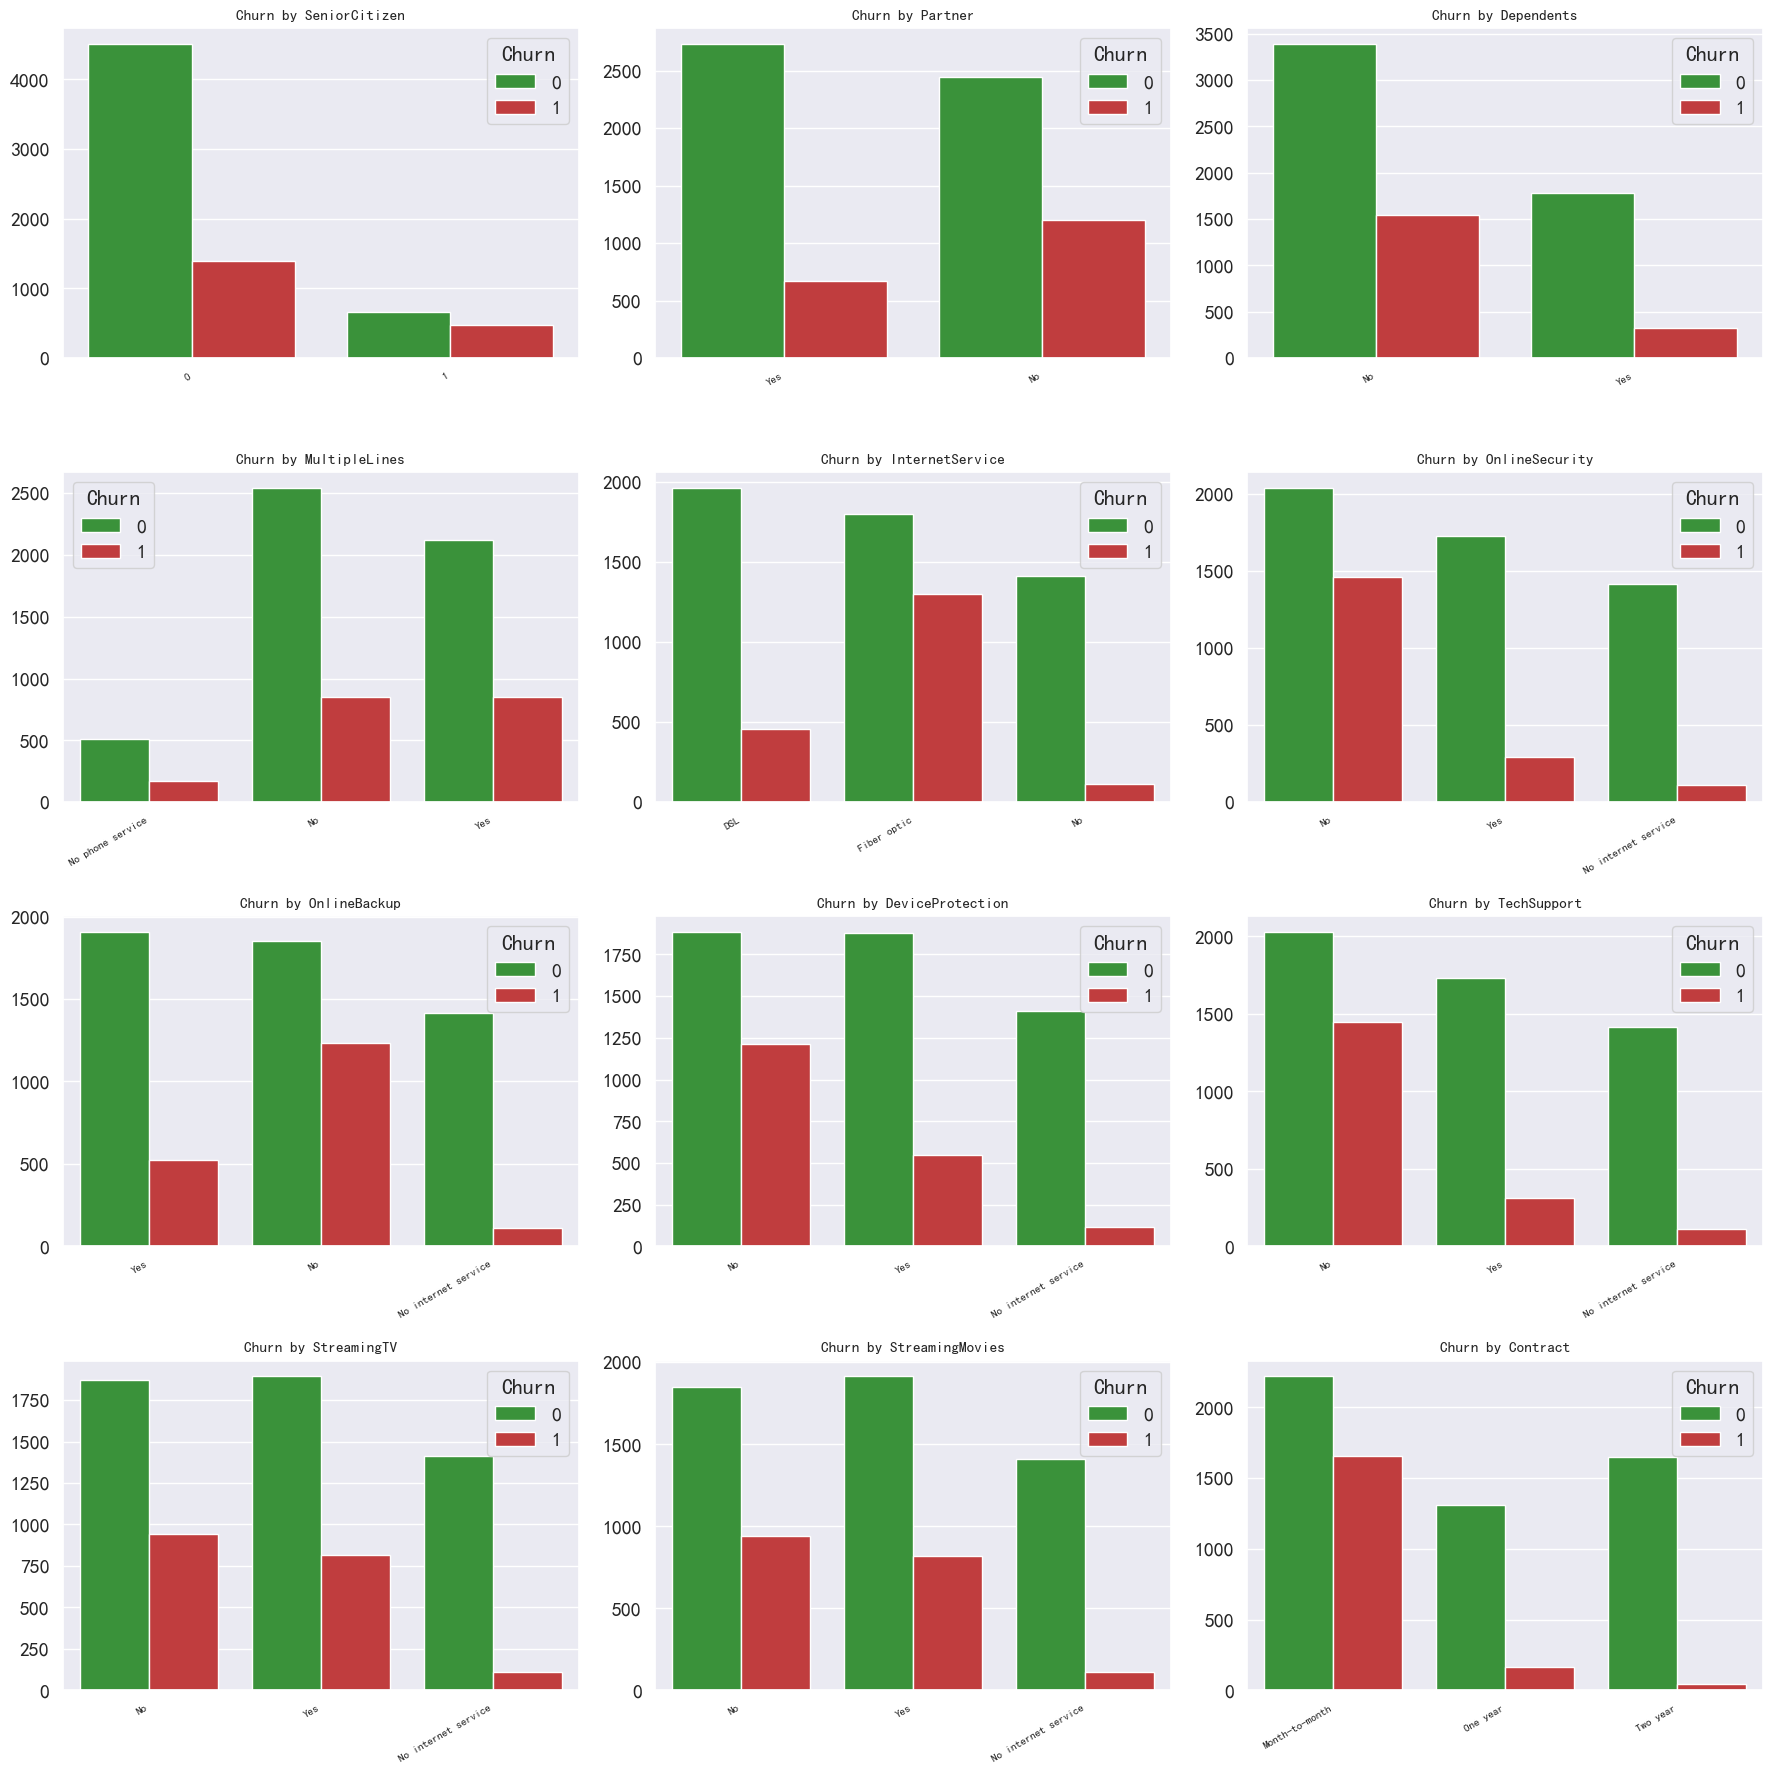

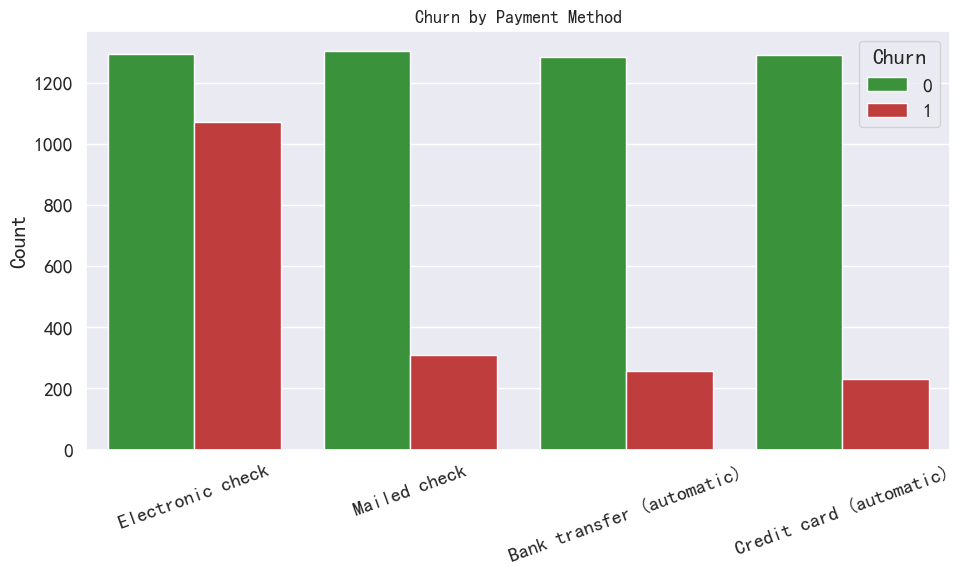

In [9]:
# ===== Multi-feature churn visualization =====

features_to_plot = [
    var for var in kf_var
    if var not in ['tenure', 'MonthlyCharges', 'PaymentMethod', 'TotalCharges']
]

plt.figure(figsize=(18, 18))

for i, k in enumerate(features_to_plot[:12]): 
    plt.subplot(4, 3, i + 1)

    sns.countplot(
        x=k,
        hue='Churn',
        data=df,
        palette=['#2ca02c', '#d62728']  # green=No churn, red=Churn
    )

    plt.title(f'Churn by {k}', fontsize=11)
    plt.xticks(rotation=30, ha='right', fontsize=8)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()


# ===== PaymentMethod single clean plot =====
plt.figure(figsize=(10, 6))

sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=df,
    palette=['#2ca02c', '#d62728']
)

plt.title('Churn by Payment Method', fontsize=13)
plt.xticks(rotation=20)
plt.xlabel('')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [10]:
import pandas as pd

cols = [var for var in kf_var if var not in ['MonthlyCharges','tenure','TotalCharges']]

result_list = []

for col in cols:
    ct = pd.crosstab(df[col], df['Churn'], normalize='index')

    for category in ct.index:
        result_list.append({
            'Feature': col,
            'Category': category,
            'No Churn Rate': ct.loc[category, 0] if 0 in ct.columns else 0,
            'Churn Rate': ct.loc[category, 1] if 1 in ct.columns else 0
        })

result_df = pd.DataFrame(result_list)

feature_risk = (
    result_df.groupby('Feature')['Churn Rate']
    .mean()
    .sort_values(ascending=False)
)

display(feature_risk.to_frame(name='Avg Churn Rate'))

result_df['Feature'] = pd.Categorical(
    result_df['Feature'],
    categories=feature_risk.index,
    ordered=True
)

result_df = result_df.sort_values(['Feature', 'Churn Rate'], ascending=[True, False])

print("\n📊 Detailed Churn Analysis Table:\n")
display(result_df)

,Avg Churn Rate
Feature,
SeniorCitizen,0.326437
Partner,0.263114
MultipleLines,0.261936
PaperlessBilling,0.249476
PaymentMethod,0.240863
StreamingMovies,0.236756
StreamingTV,0.236661
Dependents,0.233647
DeviceProtection,0.230116



📊 Detailed Churn Analysis Table:



,Feature,Category,No Churn Rate,Churn Rate
1,SeniorCitizen,1,0.583187,0.416813
0,SeniorCitizen,0,0.763938,0.236062
2,Partner,No,0.670420,0.329580
3,Partner,Yes,0.803351,0.196649
8,MultipleLines,Yes,0.713901,0.286099
6,MultipleLines,No,0.749558,0.250442
7,MultipleLines,No phone service,0.750733,0.249267
34,PaperlessBilling,Yes,0.664349,0.335651
33,PaperlessBilling,No,0.836699,0.163301
37,PaymentMethod,Electronic check,0.547146,0.452854


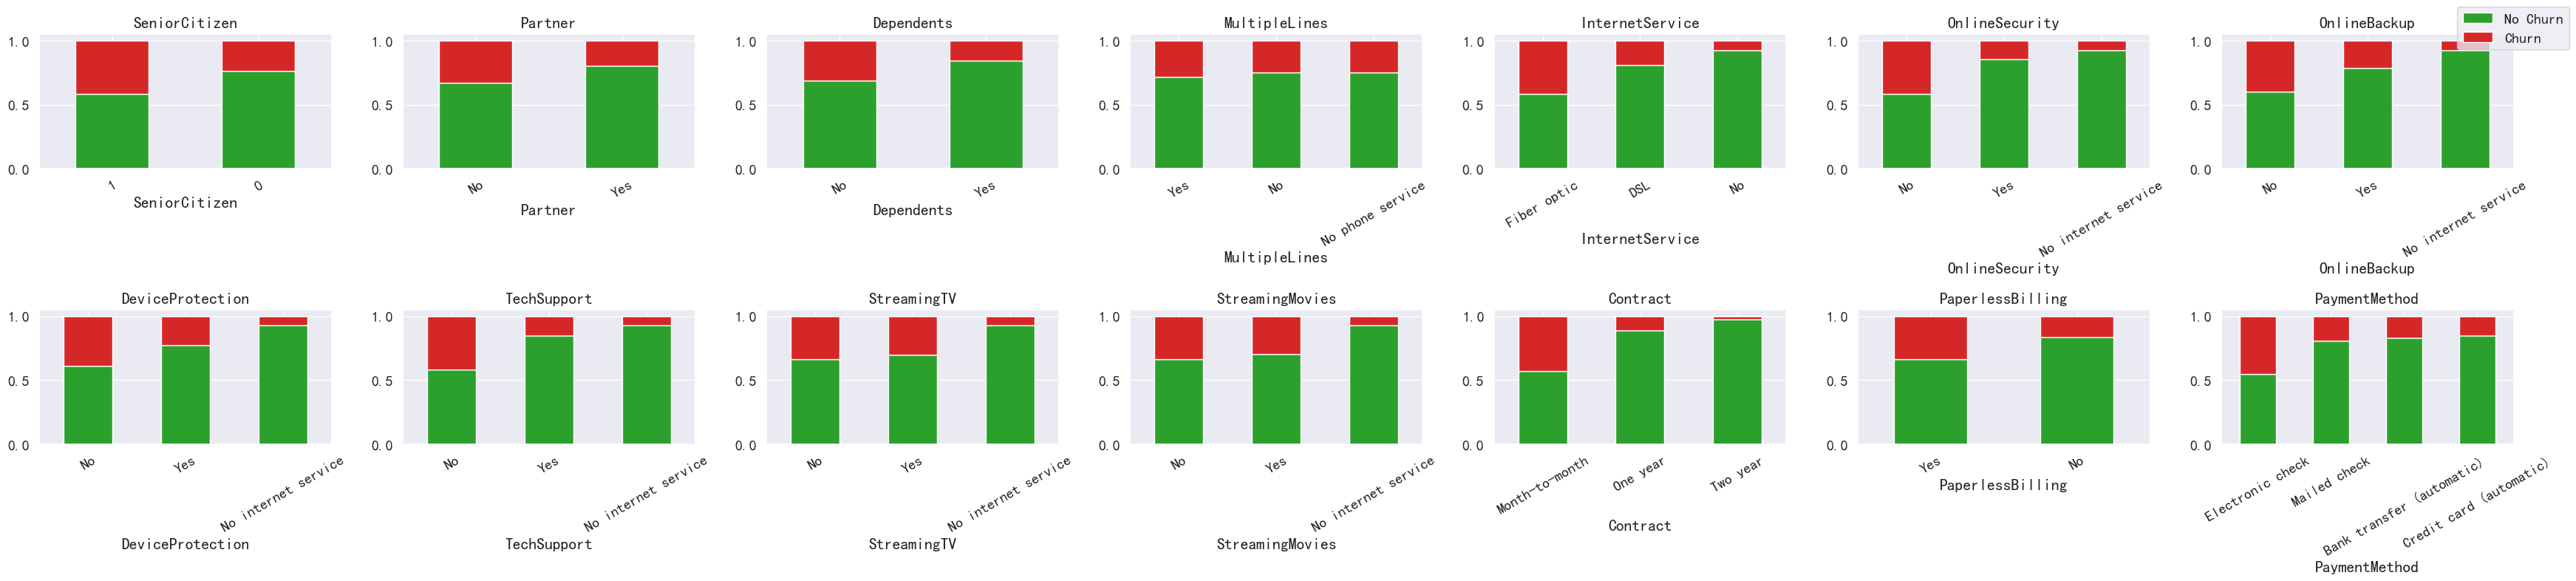

In [11]:
import math
import matplotlib.pyplot as plt
import pandas as pd

cols = [var for var in kf_var if var not in ['MonthlyCharges','tenure','TotalCharges']]

ncols = 7
nrows = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(cols[:nrows * ncols]): 

    ct = pd.crosstab(df[col], df['Churn'], normalize=0)

    if 1 in ct.columns:
        ct = ct.sort_values(by=1, ascending=False)

    ct.plot(
        kind='bar',
        stacked=True,
        ax=axes[i],
        color=['#2ca02c', '#d62728'],
        legend=False
    )

    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

for j in range(len(cols), len(axes)):
    axes[j].axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['No Churn', 'Churn'], loc='upper right')

plt.tight_layout()
plt.show()

The proportion plots are a visualization of cross-tabulation results, but they use row-wise normalization to show churn rate within each category, which is more suitable for identifying risk.

In [12]:
def ANOVA(x):
    li_index = list(df['Churn'].value_counts().keys())
    args = []
    for i in li_index:
        args.append(df[df['Churn'] == i][x])

    w, p = levene(*args)

    if p < 0.05:
        print(
            'Warning: p-value for churn by {} is {:.2e}, less than 0.05, indicating unequal variances'
            .format(x, p),
            '\n'
        )
    else:
        f, p_value = f_oneway(*args)
        print(
            'F-value for churn by {} is {:.4f}, p-value is {:.2e}'
            .format(x, f, p_value),
            '\n'
        )

        if p_value < 0.05:
            print('Significant differences in means\n')
        else:
            print('No significant differences\n')

print('Analysis results for TotalCharges, MonthlyCharges, and tenure:\n')
ANOVA('TotalCharges')
ANOVA('MonthlyCharges')
ANOVA('tenure')

Analysis results for TotalCharges, MonthlyCharges, and tenure:






In [13]:
import pandas as pd
import numpy as np

churn_var = df.iloc[:, 2:20].copy()

if 'PhoneService' in churn_var.columns:
    churn_var = churn_var.drop('PhoneService', axis=1)

numeric_cols = churn_var.select_dtypes(include=[np.number])

summary_df = pd.DataFrame({
    'Min': numeric_cols.min(),
    'Max': numeric_cols.max(),
    'Range': numeric_cols.max() - numeric_cols.min(),
    'Mean': numeric_cols.mean(),
    'Std': numeric_cols.std()
})

summary_df = summary_df.sort_values(by='Range', ascending=False)

display(summary_df)

,Min,Max,Range,Mean,Std
TotalCharges,18.80,8684.80,8666.0,2281.916928,2265.270398
MonthlyCharges,18.25,118.75,100.5,64.761692,30.090047
tenure,0.00,72.00,72.0,32.371149,24.559481
SeniorCitizen,0.00,1.00,1.0,0.162147,0.368612


The dataset exhibits significant scale heterogeneity, with TotalCharges showing a substantially larger range compared to other variables. This indicates the necessity of feature scaling prior to applying distance-based or gradient-based machine learning models.

In [14]:
from sklearn.preprocessing import StandardScaler
from IPython.display import display

num_cols = ['tenure','MonthlyCharges','TotalCharges']

scaler = StandardScaler()

churn_var[num_cols] = scaler.fit_transform(churn_var[num_cols])

display(churn_var[num_cols].head())

,tenure,MonthlyCharges,TotalCharges
0,-1.277445,-1.160323,-0.994242
1,0.066327,-0.259629,-0.173244
2,-1.236724,-0.362660,-0.959674
3,0.514251,-0.746535,-0.194766
4,-1.236724,0.197365,-0.940470


scaler = StandardScaler(copy=False)
scaler.fit_transform(churn_var[['tenure','MonthlyCharges','TotalCharges']])

churn_var[['tenure','MonthlyCharges','TotalCharges']] = scaler.transform(
    churn_var[['tenure','MonthlyCharges','TotalCharges']]
)

print(churn_var[['tenure','MonthlyCharges','TotalCharges']].head())

Feature scaling was applied using standardization to eliminate scale differences among numerical variables. This ensures that variables such as tenure, MonthlyCharges, and TotalCharges contribute equally during model training.

In [15]:
df_object = churn_var.select_dtypes(include='object').copy()
df_object['SeniorCitizen'] = churn_var['SeniorCitizen']

summary = []

for col in df_object.columns:
    summary.append({
        'Feature': col,
        'Unique Values': list(df_object[col].unique())
    })

summary_df = pd.DataFrame(summary)

display(summary_df)

,Feature,Unique Values
0,Partner,"[Yes, No]"
1,Dependents,"[No, Yes]"
2,MultipleLines,"[No phone service, No, Yes]"
3,InternetService,"[DSL, Fiber optic, No]"
4,OnlineSecurity,"[No, Yes, No internet service]"
5,OnlineBackup,"[Yes, No, No internet service]"
6,DeviceProtection,"[No, Yes, No internet service]"
7,TechSupport,"[No, Yes, No internet service]"
8,StreamingTV,"[No, Yes, No internet service]"
9,StreamingMovies,"[No, Yes, No internet service]"


Categorical variables were inspected to identify encoding strategies. Binary variables were directly label encoded, while multi-class categorical variables require one-hot encoding.

In [16]:
import pandas as pd

# ===== 1. Standardize missing-like categories =====
churn_var = churn_var.replace({
    'No internet service': 'No',
    'No phone service': 'No'
})
# ===== 2. Binary encoding (Yes/No → 1/0) =====
binary_cols = [
    'Partner','Dependents','PaperlessBilling',
    'MultipleLines',
    'OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport',
    'StreamingTV','StreamingMovies'
]
for col in binary_cols:
    churn_var[col] = churn_var[col].map({'Yes': 1, 'No': 0})
# ===== 3. Ordinal encoding =====
churn_var['Contract'] = churn_var['Contract'].map({
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
})
churn_var['InternetService'] = churn_var['InternetService'].map({
    'No': 0,
    'DSL': 1,
    'Fiber optic': 2
})
# ===== 4. One-hot encoding (nominal variable) =====
churn_var = pd.get_dummies(
    churn_var,
    columns=['PaymentMethod'],
    drop_first=True
)
# ===== 5. Numeric cleanup =====
churn_var['SeniorCitizen'] = churn_var['SeniorCitizen'].astype(int)
# ===== 6. Convert all boolean columns to int =====
bool_cols = churn_var.select_dtypes(include='bool').columns
churn_var[bool_cols] = churn_var[bool_cols].astype(int)
# ===== 7. Final check =====
print("\n📊 Data Types:\n")
display(pd.DataFrame(churn_var.dtypes, columns=['Data Type']))

print("\n📊 Data Preview:\n")
display(churn_var.head(20))


📊 Data Types:



,Data Type
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,float64
MultipleLines,int64
InternetService,int64
OnlineSecurity,int64
OnlineBackup,int64
DeviceProtection,int64
TechSupport,int64



📊 Data Preview:



,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,-1.277445,0,1,0,1,0,0,0,0,0,1,-1.160323,-0.994242,0,1,0
1,0,0,0,0.066327,0,1,1,0,1,0,0,0,1,0,-0.259629,-0.173244,0,0,1
2,0,0,0,-1.236724,0,1,1,1,0,0,0,0,0,1,-0.362660,-0.959674,0,0,1
3,0,0,0,0.514251,0,1,1,0,1,1,0,0,1,0,-0.746535,-0.194766,0,0,0
4,0,0,0,-1.236724,0,2,0,0,0,0,0,0,0,1,0.197365,-0.940470,0,1,0
5,0,0,0,-0.992402,1,2,0,0,1,0,1,1,0,1,1.159546,-0.645186,0,1,0
6,0,0,1,-0.422317,1,2,0,1,0,0,1,0,0,1,0.808907,-0.146799,1,0,0
7,0,0,0,-0.910961,0,1,1,0,0,0,0,0,0,0,-1.163647,-0.874137,0,0,1
8,0,1,0,-0.177995,1,2,0,0,1,1,1,1,0,1,1.330711,0.337349,0,1,0
9,0,0,1,1.206498,0,1,1,1,0,0,0,0,1,0,-0.286218,0.532439,0,0,0


In [17]:
from imblearn.over_sampling import SMOTE

x = churn_var
y = df['Churn']

sss = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

smote = SMOTE(random_state=0)

for train_index, test_index in sss.split(x, y):
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index] 

    x_train, y_train = smote.fit_resample(x_train, y_train)

In [18]:
Classifiers = [
['Random Forest',RandomForestClassifier()],
['Support Vector Machine',SVC()],
['LogisticRegression',LogisticRegression()],
['Naive Bayes',GaussianNB()],
['Decision Tree',DecisionTreeClassifier()],
['AdaBoostClassifier',AdaBoostClassifier()],
['GradientBoostingClassifier',GradientBoostingClassifier()],
['XGB',XGBClassifier()],
['CatBoosting',CatBoostClassifier(logging_level='Silent')]
]

classify_result = []
names = []
predictions = []

for name,classifier in Classifiers:
    classifier.fit(x_train,y_train)
    y_pred = classifier.predict(x_test)

    recall = recall_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    f1score = f1_score(y_test,y_pred)

    class_eva = pd.DataFrame([recall,precision,f1score])
    classify_result.append(class_eva)

    names.append(pd.Series(name))
    predictions.append(pd.Series(y_pred))

In [19]:
names = pd.DataFrame(names)
names = names[0].tolist()

result = pd.concat(classify_result,axis=1)
result.columns = names
result.index = ['recall','precision','f1score']

display(result)

,Random Forest,Support Vector Machine,LogisticRegression,Naive Bayes,Decision Tree,AdaBoostClassifier,GradientBoostingClassifier,XGB,CatBoosting
recall,0.636364,0.788770,0.812834,0.810160,0.558824,0.826203,0.799465,0.689840,0.700535
precision,0.556075,0.500849,0.505824,0.523316,0.458333,0.519328,0.532028,0.551282,0.552743
f1score,0.593516,0.612669,0.623590,0.635887,0.503614,0.637771,0.638889,0.612827,0.617925


Overall, boosting-based models outperform traditional machine learning models in terms of F1-score and recall, indicating their stronger capability in capturing complex patterns in churn behavior.

In [20]:
rf = RandomForestClassifier(n_estimators=100,random_state=0)
rf.fit(x_train,y_train)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

feature_names = x_train.columns

for f in range(x_train.shape[1]):
    print('{} : {}'.format(x_train.columns[indices[f]],importances[indices[f]]))

tenure : 0.17708256337728667
MonthlyCharges : 0.17387393511015525
TotalCharges : 0.16416121830642866
Contract : 0.12426787406274054
InternetService : 0.05988972723747871
OnlineSecurity : 0.035308596587966805
PaymentMethod_Electronic check : 0.03067304254511149
TechSupport : 0.02628974196302373
Partner : 0.02463928260428576
PaperlessBilling : 0.023667386915417997
OnlineBackup : 0.022772157153030704
Dependents : 0.022123508004984523
MultipleLines : 0.017610318059508107
DeviceProtection : 0.017477753607221994
StreamingMovies : 0.016882926669065924
SeniorCitizen : 0.016489032929245594
PaymentMethod_Credit card (automatic) : 0.016274368431352892
StreamingTV : 0.015896834101314018
PaymentMethod_Mailed check : 0.01461973233438072


In [21]:
importance_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\n📊 Feature Importance (Random Forest):\n")
display(importance_df)


📊 Feature Importance (Random Forest):



,Feature,Importance
3,tenure,0.177083
14,MonthlyCharges,0.173874
15,TotalCharges,0.164161
12,Contract,0.124268
5,InternetService,0.059890
6,OnlineSecurity,0.035309
17,PaymentMethod_Electronic check,0.030673
9,TechSupport,0.026290
1,Partner,0.024639
13,PaperlessBilling,0.023667


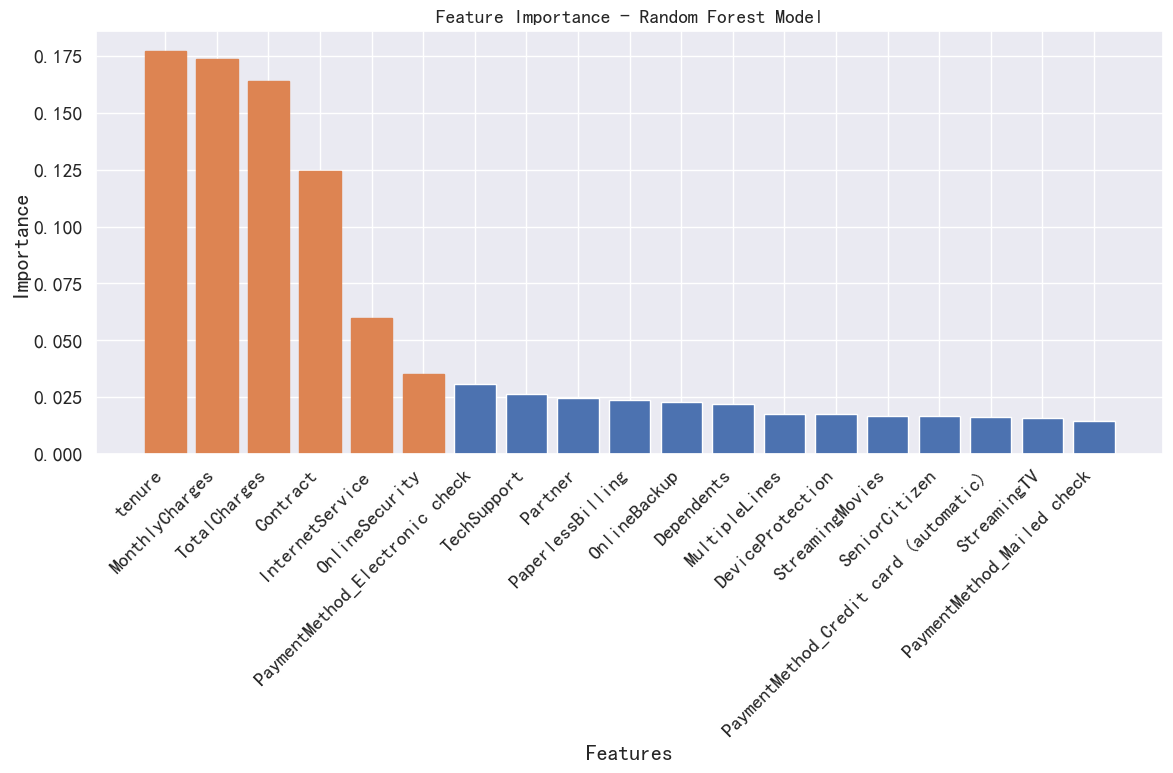

In [22]:
plt.figure(figsize=(12, 8))

# ===== Sort features =====
sorted_idx = np.argsort(importances)[::-1]
sorted_importances = importances[sorted_idx]
sorted_features = feature_names[sorted_idx]

# ===== Plot =====
bars = plt.bar(
    range(len(sorted_importances)),
    sorted_importances,
    color='#4C72B0'
)

plt.title('Feature Importance - Random Forest Model', fontsize=14)
plt.xlabel('Features')
plt.ylabel('Importance')

plt.xticks(
    range(len(sorted_importances)),
    sorted_features,
    rotation=45,
    ha='right'
)

# ===== Highlight top features =====
for i in range(min(6, len(bars))):
    bars[i].set_color('#DD8452')  # highlight top 5

plt.tight_layout()
plt.show()

In [23]:
# ===== Logistic Regression Feature Importance =====
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)

coefficients = lr.coef_[0]

feature_names = x_train.columns

lr_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
})

lr_importance_df['Abs_Importance'] = np.abs(lr_importance_df['Importance'])
lr_importance_df = lr_importance_df.sort_values(by='Abs_Importance', ascending=False)

print("\n📊 Logistic Regression Feature Importance:\n")
display(lr_importance_df)


📊 Logistic Regression Feature Importance:



,Feature,Importance,Abs_Importance
3,tenure,-1.392757,1.392757
15,TotalCharges,0.940345,0.940345
6,OnlineSecurity,-0.915710,0.915710
12,Contract,-0.854301,0.854301
14,MonthlyCharges,0.752841,0.752841
9,TechSupport,-0.694460,0.694460
18,PaymentMethod_Mailed check,-0.654981,0.654981
16,PaymentMethod_Credit card (automatic),-0.576591,0.576591
7,OnlineBackup,-0.501785,0.501785
2,Dependents,-0.453868,0.453868


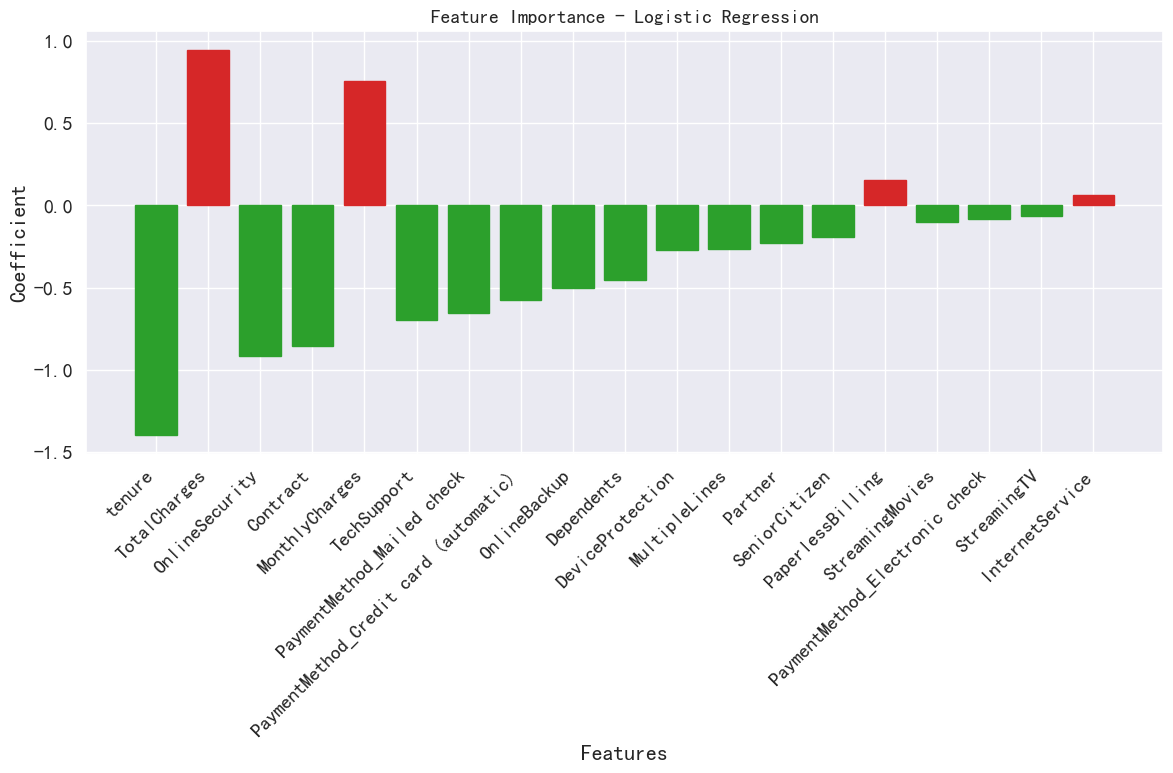

In [24]:
plt.figure(figsize=(12, 8))

sorted_features = lr_importance_df['Feature']
sorted_importances = lr_importance_df['Importance']

bars = plt.bar(
    range(len(sorted_importances)),
    sorted_importances,
    color='#4C72B0'
)

plt.title('Feature Importance - Logistic Regression', fontsize=14)
plt.xlabel('Features')
plt.ylabel('Coefficient')

plt.xticks(
    range(len(sorted_features)),
    sorted_features,
    rotation=45,
    ha='right'
)

for i, v in enumerate(sorted_importances):
    if v > 0:
        bars[i].set_color('#D62728')  # red = increase churn risk
    else:
        bars[i].set_color('#2CA02C')  # green = decrease churn risk

plt.tight_layout()
plt.show()

In [25]:
# ===== Naive Bayes Feature Importance (proxy) =====
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(x_train, y_train)

# variance of each feature per class (proxy importance)
nb_importance = np.abs(nb.theta_[1] - nb.theta_[0])

feature_names = x_train.columns

nb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': nb_importance
})

nb_importance_df = nb_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\n📊 Naive Bayes Feature Importance (approx):\n")
display(nb_importance_df)


📊 Naive Bayes Feature Importance (approx):



,Feature,Importance
3,tenure,0.809964
12,Contract,0.768302
5,InternetService,0.541194
15,TotalCharges,0.457090
14,MonthlyCharges,0.424372
17,PaymentMethod_Electronic check,0.294516
1,Partner,0.229282
6,OnlineSecurity,0.227350
9,TechSupport,0.210679
2,Dependents,0.210437


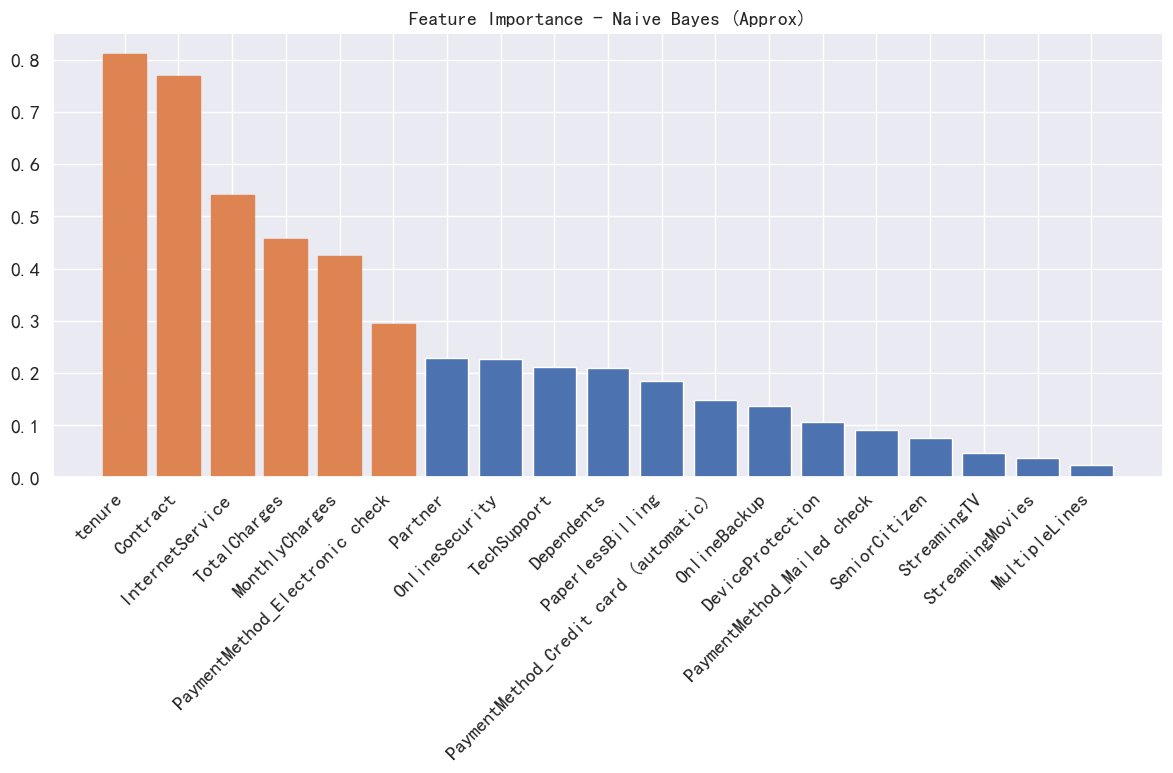

In [26]:
# ===== Sort (important) =====
nb_sorted = nb_importance_df.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

sorted_features = nb_sorted['Feature']
sorted_importances = nb_sorted['Importance']

plt.figure(figsize=(12, 8))

bars = plt.bar(
    range(len(sorted_importances)),
    sorted_importances,
    color='#4C72B0'
)

plt.title('Feature Importance - Naive Bayes (Approx)', fontsize=14)

plt.xticks(
    range(len(sorted_features)),
    sorted_features,
    rotation=45,
    ha='right'
)

# ===== highlight top 6 =====
for i in range(min(6, len(bars))):
    bars[i].set_color('#DD8452')

plt.tight_layout()
plt.show()

In [27]:
# ===== Gradient Boosting Feature Importance =====
gb = GradientBoostingClassifier()
gb.fit(x_train, y_train)

gb_importances = gb.feature_importances_

gb_importance_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': gb_importances
})

gb_importance_df = gb_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\n📊 Gradient Boosting Feature Importance:\n")
display(gb_importance_df)


📊 Gradient Boosting Feature Importance:



,Feature,Importance
12,Contract,0.522722
3,tenure,0.139682
5,InternetService,0.089716
14,MonthlyCharges,0.082782
6,OnlineSecurity,0.038551
15,TotalCharges,0.035618
9,TechSupport,0.021375
18,PaymentMethod_Mailed check,0.012179
2,Dependents,0.011562
7,OnlineBackup,0.010108


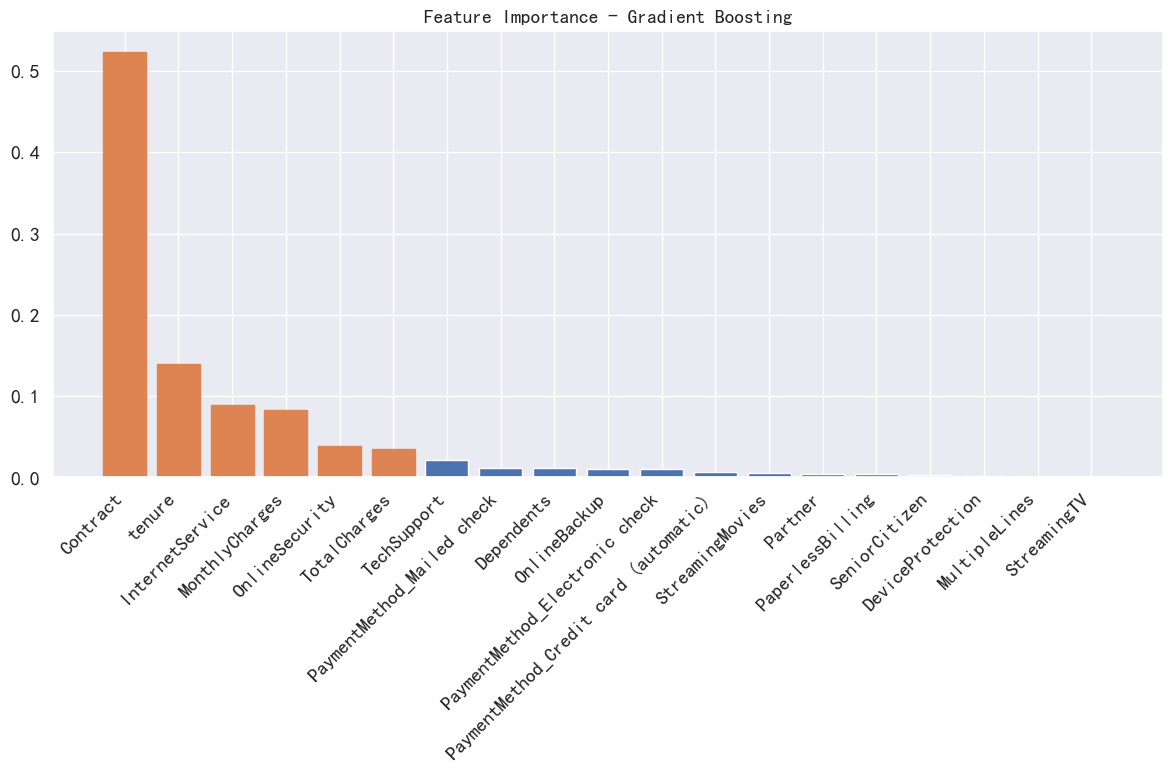

In [28]:
plt.figure(figsize=(12, 8))

sorted_features = gb_importance_df['Feature']
sorted_importances = gb_importance_df['Importance']

bars = plt.bar(
    range(len(sorted_importances)),
    sorted_importances,
    color='#4C72B0'
)

plt.title('Feature Importance - Gradient Boosting', fontsize=14)
plt.xticks(
    range(len(sorted_features)),
    sorted_features,
    rotation=45,
    ha='right'
)

# highlight top features
for i in range(min(6, len(bars))):
    bars[i].set_color('#DD8452')

plt.tight_layout()
plt.show()

In [29]:
lr_importance_df['rank_lr'] = lr_importance_df['Abs_Importance'].rank(ascending=False)

nb_importance_df['rank_nb'] = nb_importance_df['Importance'].rank(ascending=False)

gb_importance_df['rank_gb'] = gb_importance_df['Importance'].rank(ascending=False)

merged = lr_importance_df[['Feature','rank_lr']].merge(
    nb_importance_df[['Feature','rank_nb']],
    on='Feature'
).merge(
    gb_importance_df[['Feature','rank_gb']],
    on='Feature'
)

merged['final_rank'] = merged[['rank_lr','rank_nb','rank_gb']].mean(axis=1)

final_result = merged.sort_values('final_rank')

display(final_result)

,Feature,rank_lr,rank_nb,rank_gb,final_rank
0,tenure,1.0,1.0,2.0,1.333333
3,Contract,4.0,2.0,1.0,2.333333
1,TotalCharges,2.0,4.0,6.0,4.000000
4,MonthlyCharges,5.0,5.0,4.0,4.666667
2,OnlineSecurity,3.0,8.0,5.0,5.333333
5,TechSupport,6.0,9.0,7.0,7.333333
18,InternetService,19.0,3.0,3.0,8.333333
9,Dependents,10.0,10.0,9.0,9.666667
6,PaymentMethod_Mailed check,7.0,15.0,8.0,10.000000
7,PaymentMethod_Credit card (automatic),8.0,12.0,12.0,10.666667


In [30]:
print('Analysis of the features', df[['MonthlyCharges', 'TotalCharges']].describe())

mc = df['MonthlyCharges_kf'] = pd.qcut(df['MonthlyCharges'], q=4, labels=[1,2,3,4])
tc = df['TotalCharges_kf'] = pd.qcut(df['TotalCharges'], q=4, labels=[1,2,3,4])

df['MonthlyCharges_kf'] = mc
df['TotalCharges_kf'] = tc

KF('MonthlyCharges_kf')
KF('TotalCharges_kf')

Analysis of the features        MonthlyCharges  TotalCharges
count     7043.000000   7043.000000
mean        64.761692   2281.916928
std         30.090047   2265.270398
min         18.250000     18.800000
25%         35.500000    402.225000
50%         70.350000   1397.475000
75%         89.850000   3786.600000
max        118.750000   8684.800000
Chi-square test p-value for churn by MonthlyCharges_kf is 1.14e-77, less than 0.05, indicating significant differences between groups, suitable for [cross-analysis] 

Chi-square test p-value for churn by TotalCharges_kf is 2.10e-86, less than 0.05, indicating significant differences between groups, suitable for [cross-analysis] 



In [31]:
for i in ['MonthlyCharges_kf','TotalCharges_kf']:
    print('...............churn by {}...............'.format(i))
    print(pd.crosstab(df['Churn'],df[i],normalize=0),'\n')

...............churn by MonthlyCharges_kf...............
MonthlyCharges_kf         1         2         3         4
Churn                                                    
0                  0.302281  0.257441  0.212215  0.228063
1                  0.105939  0.232210  0.352595  0.309256 

...............churn by TotalCharges_kf...............
TotalCharges_kf         1         2         3         4
Churn                                                  
0                0.192694  0.255315  0.260920  0.291071
1                0.408775  0.238095  0.216693  0.136437 



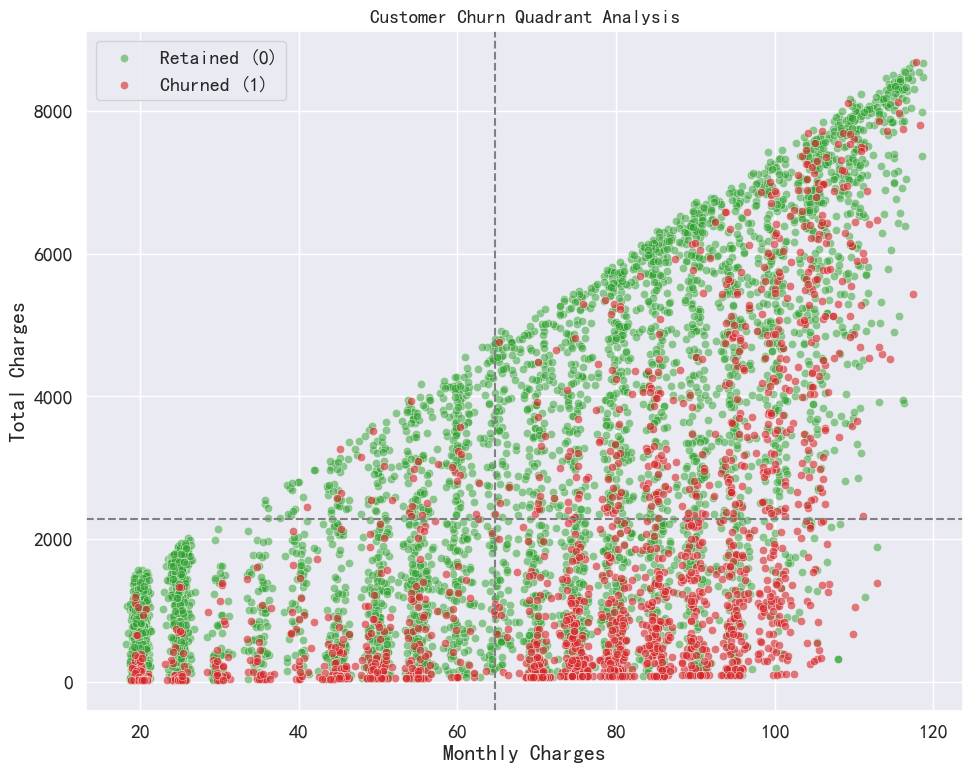

In [32]:
# ===== Split data =====
df_1 = df[df['Churn'] == 1]
df_0 = df[df['Churn'] == 0]

plt.figure(figsize=(10, 8))

# ===== Plot both groups clearly =====
sns.scatterplot(
    x='MonthlyCharges',
    y='TotalCharges',
    data=df_0,
    label='Retained (0)',
    alpha=0.5,
    color='#2ca02c'
)

sns.scatterplot(
    x='MonthlyCharges',
    y='TotalCharges',
    data=df_1,
    label='Churned (1)',
    alpha=0.6,
    color='#d62728'
)

# ===== Reference lines =====
plt.axhline(y=df['TotalCharges'].mean(), linestyle='--', c='gray')
plt.axvline(x=df['MonthlyCharges'].mean(), linestyle='--', c='gray')

# ===== Labels =====
plt.title('Customer Churn Quadrant Analysis', fontsize=14)
plt.xlabel('Monthly Charges')
plt.ylabel('Total Charges')

plt.legend()
plt.tight_layout()
plt.show()

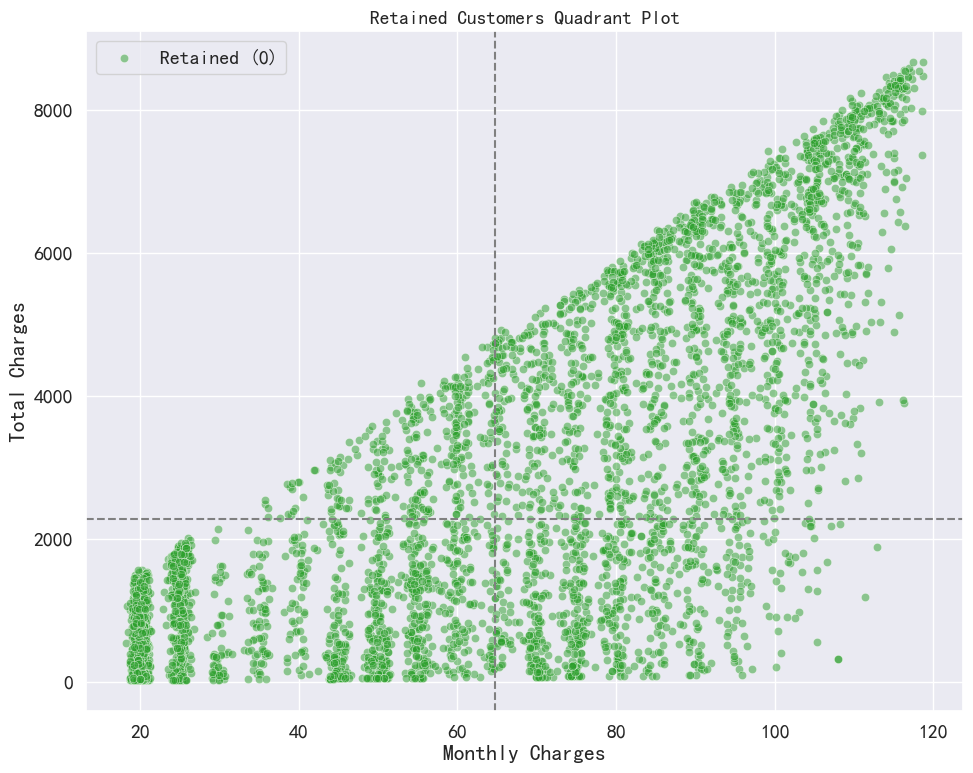

In [33]:
plt.figure(figsize=(10, 8))

# ===== Retained customers only =====
sns.scatterplot(
    x='MonthlyCharges',
    y='TotalCharges',
    data=df_0,
    color='#2ca02c',
    alpha=0.5,
    label='Retained (0)'
)

# ===== Reference lines =====
plt.axhline(y=df['TotalCharges'].mean(), linestyle='--', c='gray')
plt.axvline(x=df['MonthlyCharges'].mean(), linestyle='--', c='gray')

# ===== Labels =====
plt.title('Retained Customers Quadrant Plot', fontsize=14)
plt.xlabel('Monthly Charges')
plt.ylabel('Total Charges')

plt.legend()
plt.tight_layout()
plt.show()

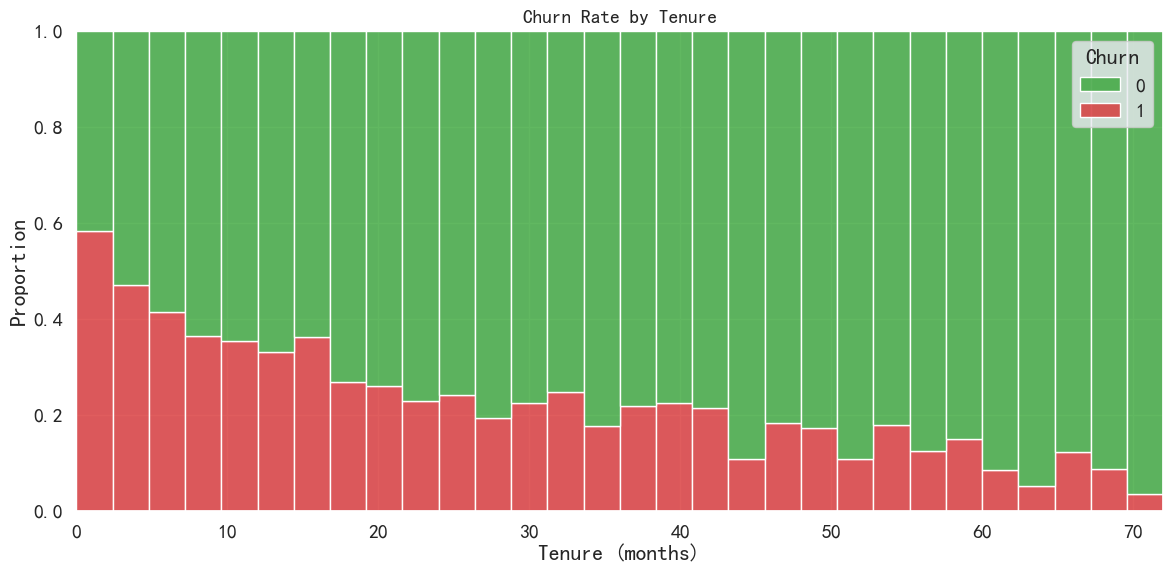

In [34]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    multiple='fill',
    bins=30,
    palette=['#2ca02c', '#d62728']
)

plt.title('Churn Rate by Tenure', fontsize=14)
plt.xlabel('Tenure (months)')
plt.ylabel('Proportion')

plt.tight_layout()
plt.show()

In [35]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import umap.umap_ as umap

import warnings
warnings.filterwarnings('ignore')

In [36]:
data = churn_var.copy()

In [37]:
data_model = pd.get_dummies(data)

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_model)

In [39]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
data_model["Cluster"] = clusters

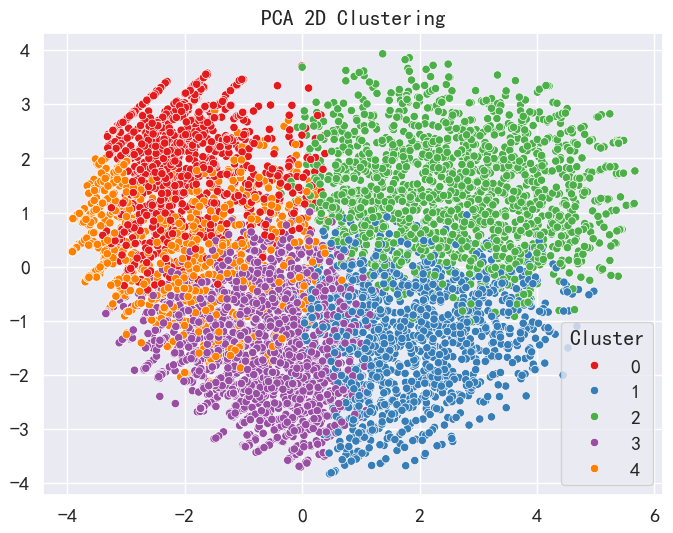

In [40]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=data_model["Cluster"],  
    palette='Set1'
)

plt.title('PCA 2D Clustering')
plt.show()

In [41]:
import plotly.express as px

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca_3d, columns=['PC1','PC2','PC3'])
pca_df['Cluster'] = data_model['Cluster'].astype(str)

fig = px.scatter_3d(
    pca_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Cluster',
    title='PCA 3D Clustering'
)

fig.update_traces(marker=dict(size=3))
fig.show()

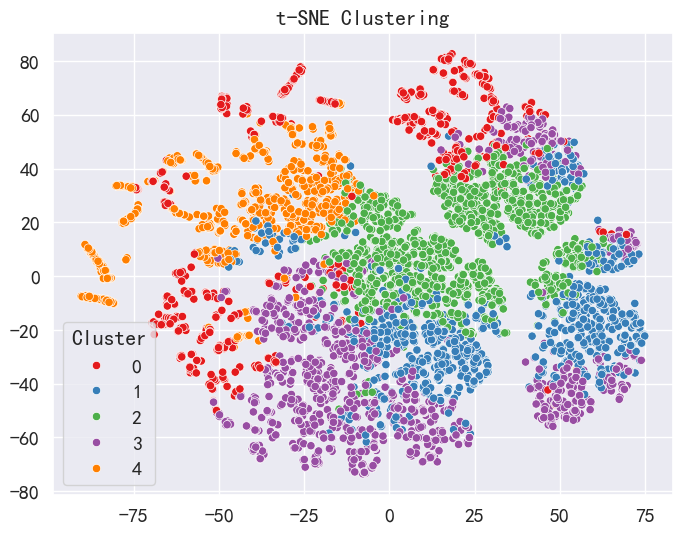

In [42]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_tsne[:,0],
    y=X_tsne[:,1],
    hue=data_model['Cluster'],
    palette='Set1'
)
plt.title('t-SNE Clustering')
plt.show()

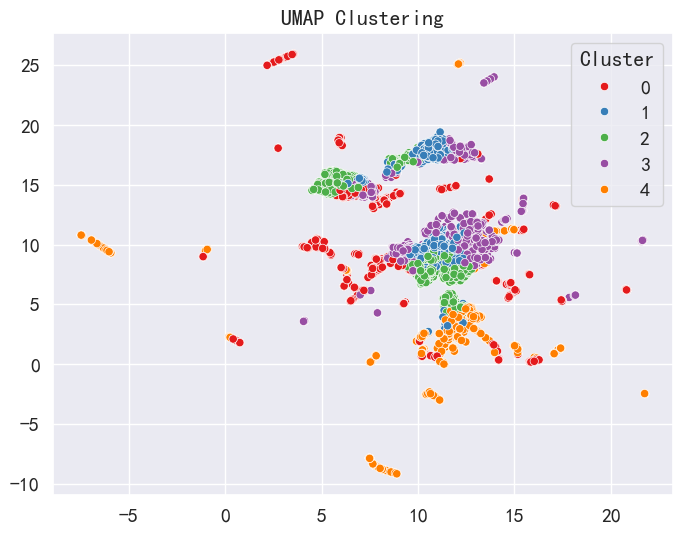

In [43]:
import umap.umap_ as umap

reducer = umap.UMAP(random_state=42)
X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_umap[:,0],
    y=X_umap[:,1],
    hue=data_model['Cluster'],
    palette='Set1'
)
plt.title('UMAP Clustering')
plt.show()

In [44]:
data_model["Cluster"] = clusters
data_model["Churn"] = df["Churn"].values


📊 Cluster Profile (Sorted by Churn ↓)



,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn,Count
Cluster,,,,,,,,,,,,,,,,,,,,,
3,0.186269,0.255455,0.144758,-0.781454,0.296434,1.560937,0.179351,0.227249,0.179351,0.160724,0.257584,0.263438,0.059606,0.712081,0.073580,-0.622536,0.134114,0.709952,0.000532,0.489090,1879
1,0.417317,0.579563,0.195008,0.275043,0.775351,1.890796,0.184867,0.528081,0.564743,0.216069,0.800312,0.788612,0.329953,0.836973,0.959513,0.603645,0.135725,0.594384,0.052262,0.401716,1282
4,0.057216,0.239112,0.233134,-0.818149,0.125534,0.684031,0.178480,0.142613,0.118702,0.166524,0.081981,0.087105,0.314261,0.409906,-0.824671,-0.782345,0.000000,0.000000,0.957301,0.237404,1171
2,0.092698,0.724444,0.432381,1.060938,0.600000,1.445079,0.738413,0.706032,0.749206,0.769524,0.687619,0.704127,1.528254,0.596190,0.691969,1.229448,0.415873,0.120000,0.106667,0.070476,1575
0,0.038732,0.667254,0.558099,0.354596,0.288732,0.157570,0.064261,0.040493,0.036972,0.051056,0.015845,0.013204,1.367077,0.300176,-1.313833,-0.549633,0.388204,0.070423,0.224472,0.040493,1136


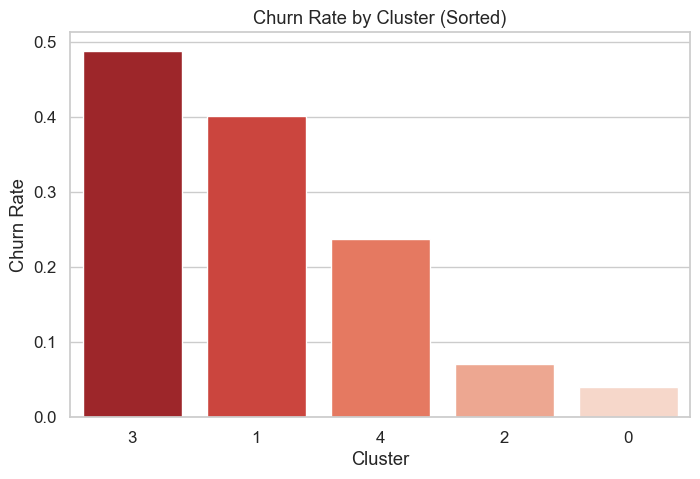

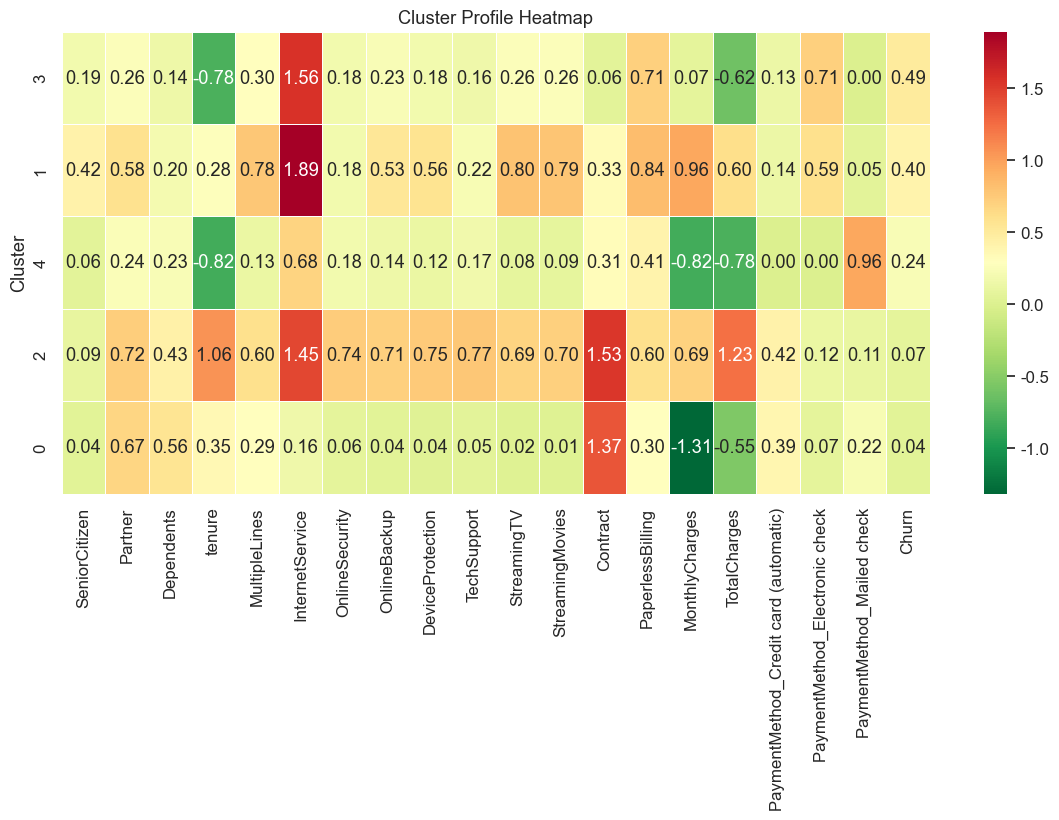

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.1)

cluster_profile = data_model.groupby("Cluster").mean(numeric_only=True)

cluster_profile["Churn"] = data_model.groupby("Cluster")["Churn"].mean()
cluster_profile["Count"] = data_model["Cluster"].value_counts()

cluster_profile = cluster_profile.sort_values(by="Churn", ascending=False)

print("\n📊 Cluster Profile (Sorted by Churn ↓)\n")
display(cluster_profile)

plt.figure(figsize=(8,5))

sns.barplot(
    x=cluster_profile.index,
    y=cluster_profile["Churn"],
    order=cluster_profile.index, 
    palette="Reds_r"
)

plt.title("Churn Rate by Cluster (Sorted)")
plt.xlabel("Cluster")
plt.ylabel("Churn Rate")

plt.show()

plt.figure(figsize=(14,6))

sns.heatmap(
    cluster_profile.drop(columns=["Count"]),
    cmap="RdYlGn_r",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Cluster Profile Heatmap")
plt.show()